In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv(r"C:\Users\Lavanya m\OneDrive\Desktop\Task 3 Deep-Dive Analysis & Interactive Dashboard\dataset\ecommerce_sales_34500.csv")
df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [3]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  object 
 11  returned            34500 non-null  object 
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  cust

(34500, 17)

In [4]:
df.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

In [5]:
df['customer_gender'] = df['customer_gender'].fillna('Unknown')
df['region'] = df['region'].fillna('Unknown')
df['payment_method'] = df['payment_method'].fillna('Unknown')

In [6]:
df = df.drop_duplicates()

In [7]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [8]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['total_amount'] = pd.to_numeric(df['total_amount'], errors='coerce')
df['profit_margin'] = pd.to_numeric(df['profit_margin'], errors='coerce')

In [9]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()

In [10]:
# Total Sales
total_sales = df['total_amount'].sum()

# Total Orders
total_orders = df['order_id'].nunique()

# Average Order Value
aov = total_sales / total_orders

# Total Profit
total_profit = df['profit_margin'].sum()

print(total_sales,
 total_orders,
  aov, 
  total_profit)

5865293.05 34500 170.00849420289853 970019.41


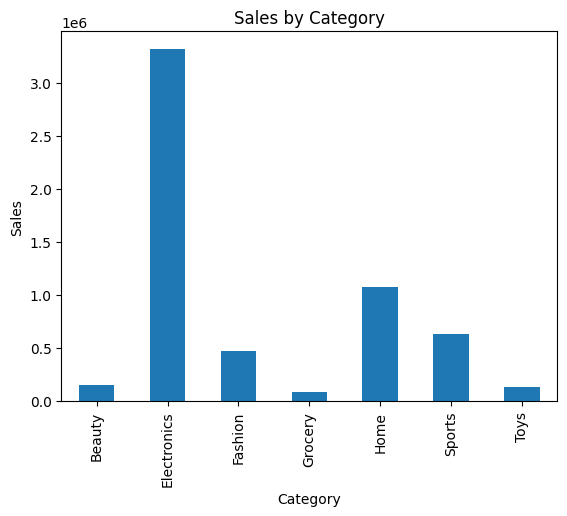

In [11]:
category_analysis = df.groupby('category')['total_amount'].sum()

category_analysis.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

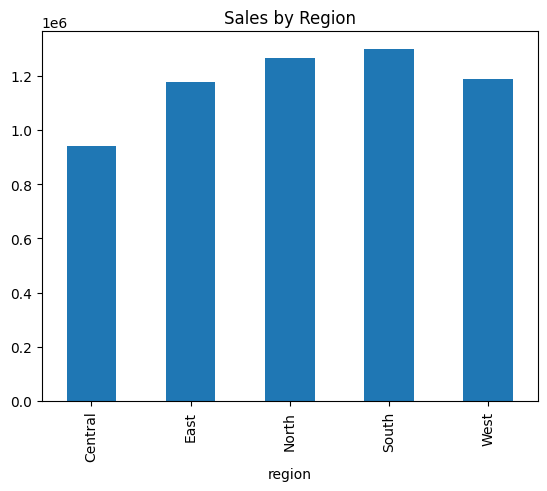

In [12]:
region_analysis = df.groupby('region')['total_amount'].sum()

region_analysis.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

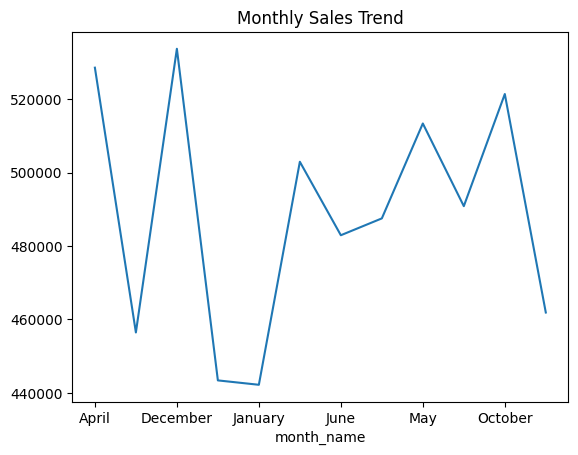

In [13]:
monthly_sales = df.groupby('month_name')['total_amount'].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

In [14]:
top_customers = df.groupby('customer_id')['total_amount'].sum().sort_values(ascending=False).head(10)

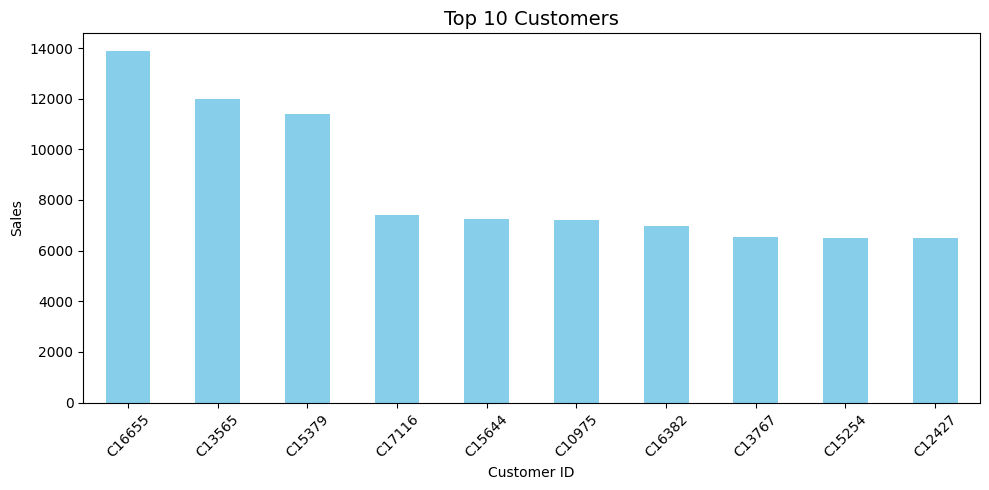

In [15]:
import matplotlib.pyplot as plt

top_customers.plot(kind='bar', color='skyblue', figsize=(10,5))

plt.title("Top 10 Customers", fontsize=14)
plt.xlabel("Customer ID")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
loss_data = df[df['profit_margin'] < 0]

In [17]:
loss_data.head()
loss_data.shape

(6104, 20)

In [18]:
total_loss = loss_data['profit_margin'].sum()
print("Total Loss:", total_loss)

Total Loss: -11672.32


In [19]:
loss_by_category = loss_data.groupby('category')['profit_margin'].sum().sort_values()

loss_by_category

category
Grocery       -9580.76
Toys           -893.20
Fashion        -487.92
Beauty         -430.27
Home           -149.20
Sports          -86.27
Electronics     -44.70
Name: profit_margin, dtype: float64

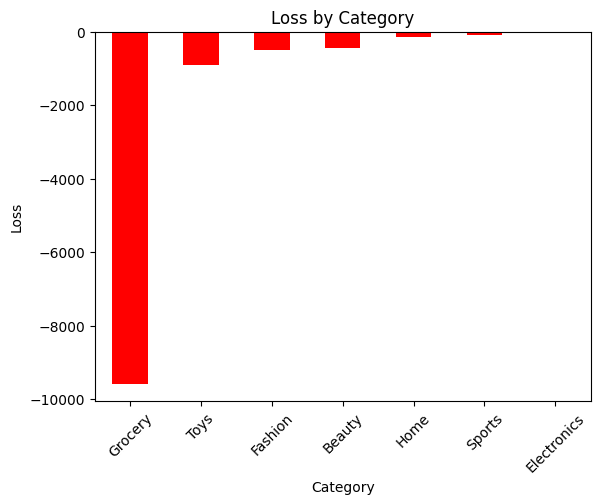

In [20]:
import matplotlib.pyplot as plt

loss_by_category.plot(kind='bar', color='red')

plt.title("Loss by Category")
plt.xlabel("Category")
plt.ylabel("Loss")
plt.xticks(rotation=45)
plt.show()

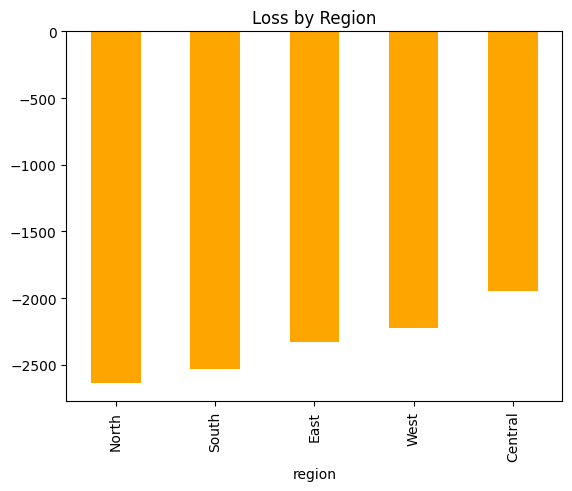

In [21]:
loss_by_region = loss_data.groupby('region')['profit_margin'].sum().sort_values()

loss_by_region.plot(kind='bar', color='orange')

plt.title("Loss by Region")
plt.show()

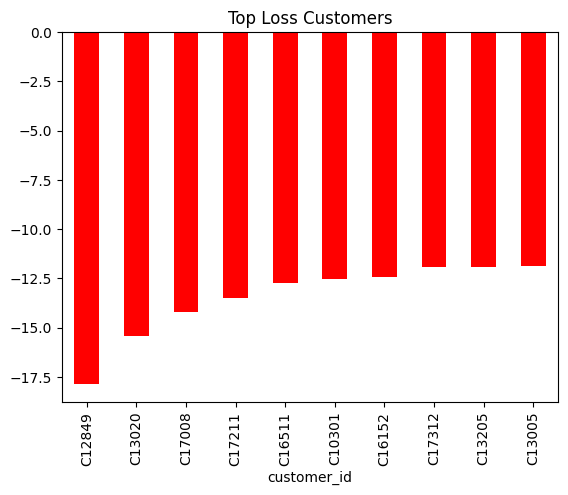

In [22]:
top_loss_customers = loss_data.groupby('customer_id')['profit_margin'].sum().sort_values().head(10)

top_loss_customers.plot(kind='bar', color='red')
plt.title("Top Loss Customers")
plt.show()

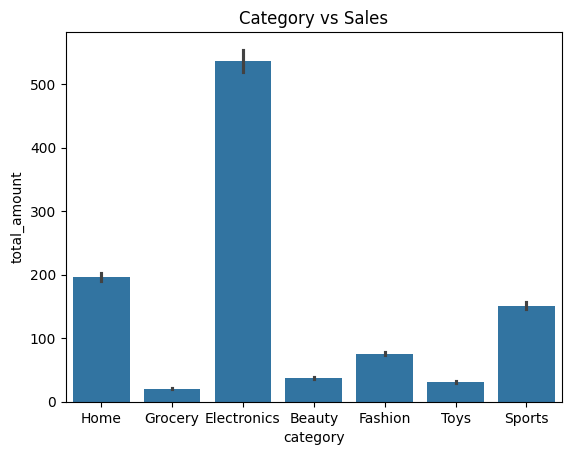

In [23]:
sns.barplot(x='category', y='total_amount', data=df)
plt.title("Category vs Sales")
plt.show()

In [24]:
df.to_csv("cleaned_data.csv", index=False)